In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
tf.config.run_functions_eagerly(True)


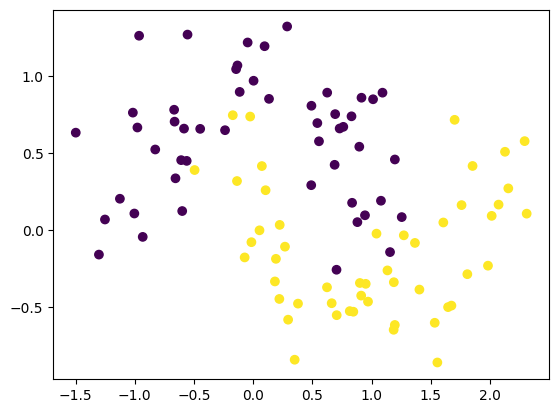

In [3]:
from sklearn.datasets import make_moons
X, y = make_moons(100, noise=0.25, random_state=2)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

In [4]:
model = Sequential([
    Input(shape=(2,)),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
adam=Adam(learning_rate=0.01)
model.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer=adam)

In [6]:
history1=model.fit(X,y,validation_split=0.2,epochs=2000,verbose=0)

c:\Coding\ML_DL\dl\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


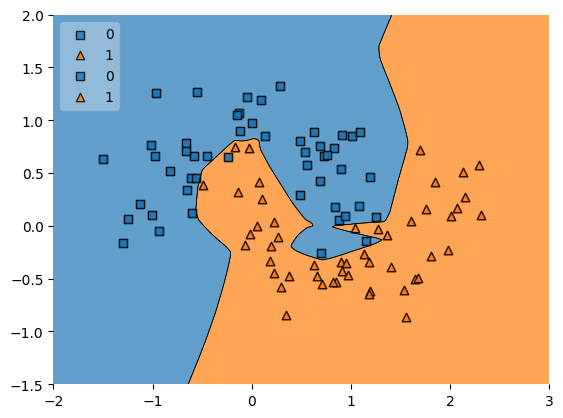

In [7]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype(int),clf=model,legend=2)
plot_decision_regions(X,y.astype(int),clf=model,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

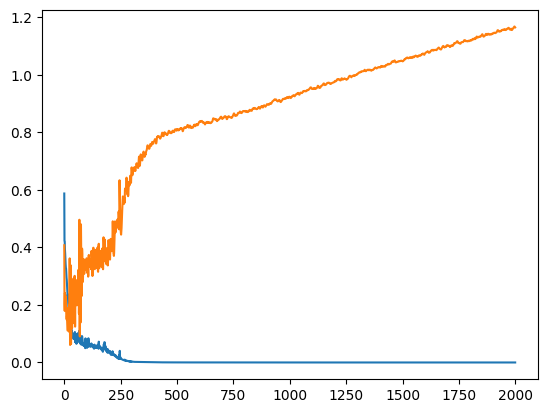

In [8]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

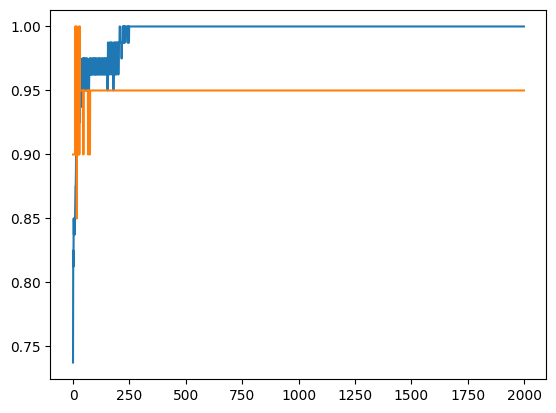

In [9]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

In [11]:
model1= Sequential([
    Input(shape=(2,)),
    Dense(128, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.03)),
    Dense(128, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(0.03)),
    Dense(1, activation="sigmoid")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,077 (199.52 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 34,052 (133.02 KB)

In [12]:
model1.compile(loss='binary_crossentropy',metrics=['accuracy'],optimizer=Adam(learning_rate=0.01))
history2=model1.fit(X,y,validation_split=0.2,epochs=500,verbose=0)


  82/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step

C:\Users\narin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tensorflow\python\data\ops\structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step
9600/9600 ━━━━━━━━━━━━━━━━━━━━ 18s 2ms/step


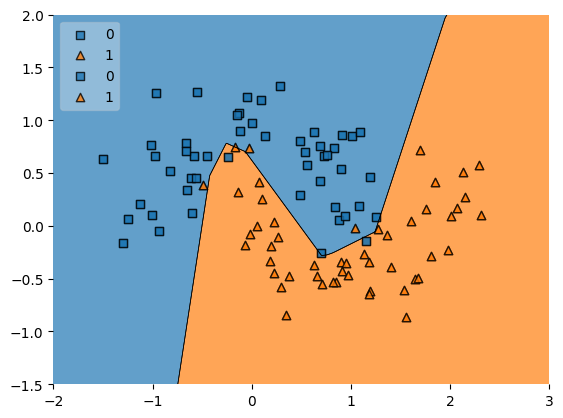

In [30]:
plot_decision_regions(X,y.astype(int),clf=model1,legend=2)
plot_decision_regions(X,y.astype(int),clf=model1,legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

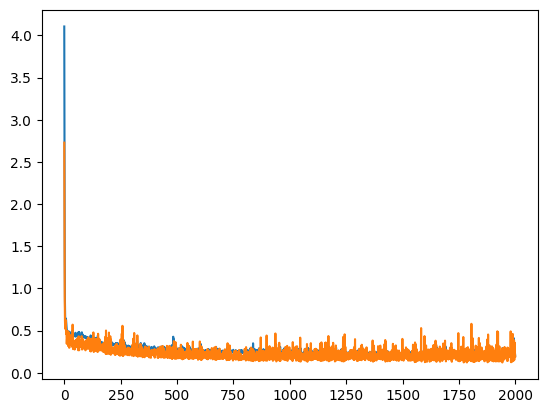

In [31]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

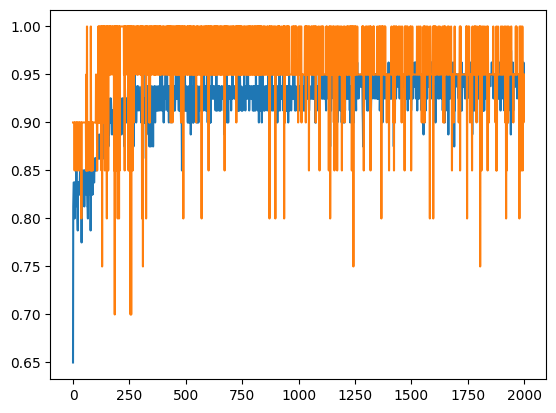

In [32]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

In [40]:
without_regularization_layer1=model.get_weights()[0].reshape((256,))
with_regularization_layer1=model1.get_weights()[0].reshape((256,))

<Axes: >

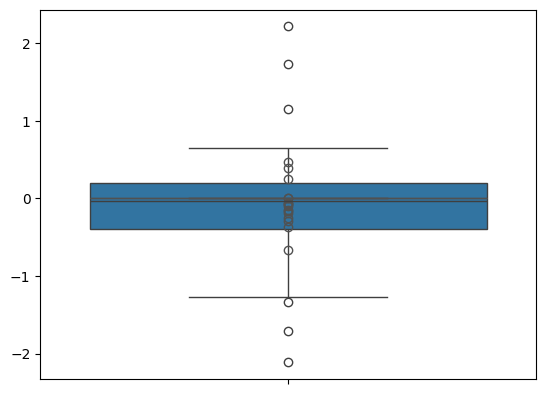

In [43]:
import seaborn as sns
sns.boxplot(without_regularization_layer1)
sns.boxplot(with_regularization_layer1)

C:\Users\narin\AppData\Local\Temp\ipykernel_15556\1033000681.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(with_regularization_layer1)
C:\Users\narin\AppData\Local\Temp\ipykernel_15556\1033000681.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(without_regularization_layer1)


<Axes: ylabel='Density'>

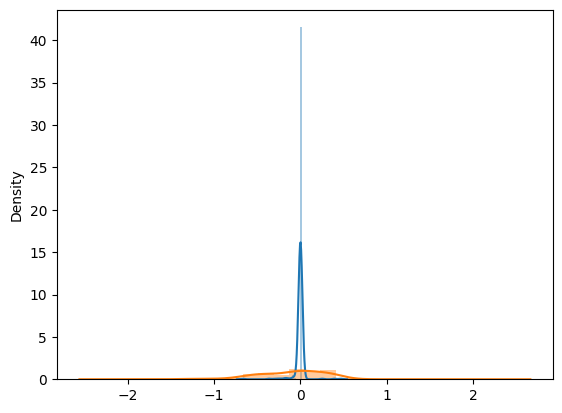

In [45]:
sns.distplot(with_regularization_layer1)
sns.distplot(without_regularization_layer1)